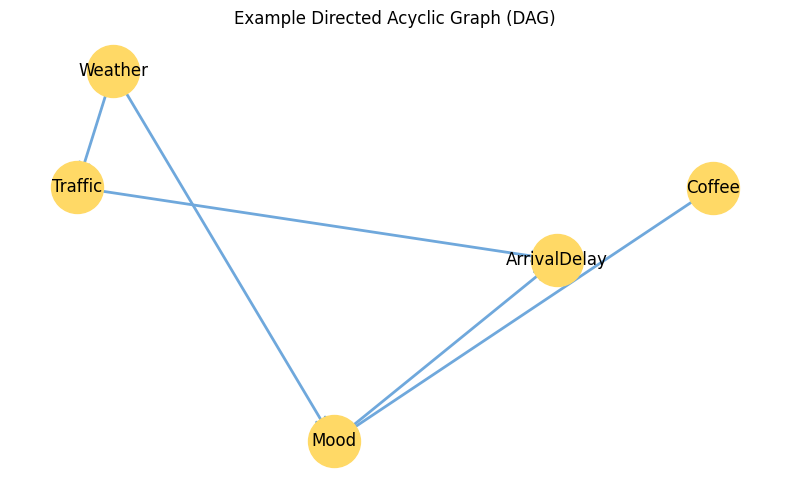

Nodes: ['Weather', 'Traffic', 'Mood', 'ArrivalDelay', 'Coffee']
Edges: [('Weather', 'Traffic'), ('Weather', 'Mood'), ('Traffic', 'ArrivalDelay'), ('Coffee', 'Mood'), ('Mood', 'ArrivalDelay')]
Is DAG: True
Topological order: ['Weather', 'Coffee', 'Traffic', 'Mood', 'ArrivalDelay']
Adjacency matrix:
 [[0 1 1 0 0]
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]
Saved plot to /mnt/data/dag.png


In [2]:
# Re-run: Create a DAG and produce outputs.
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Define a small DAG
G = nx.DiGraph()
edges = [
    ("Weather", "Traffic"),
    ("Weather", "Mood"),
    ("Traffic", "ArrivalDelay"),
    ("Coffee", "Mood"),
    ("Mood", "ArrivalDelay"),
]
G.add_edges_from(edges)

# Check DAG property and get topo order
is_dag = nx.is_directed_acyclic_graph(G)
topo_order = list(nx.topological_sort(G))

# Adjacency matrix
nodes = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodes, dtype=int)

# Plot
plt.figure(figsize=(8,5))
pos = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, pos, node_size=1400, node_color="#ffd966")
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=18, edge_color="#6fa8dc", width=2)
nx.draw_networkx_labels(G, pos, font_size=12)
plt.title("Example Directed Acyclic Graph (DAG)")
plt.axis('off')
plt.tight_layout()
plt.savefig("dag.png", dpi=150)
plt.show()

print("Nodes:", nodes)
print("Edges:", edges)
print("Is DAG:", is_dag)
print("Topological order:", topo_order)
print("Adjacency matrix:\n", A)
print("Saved plot to /mnt/data/dag.png")


A directed graph just means edges have arrows (direction matters). Cycles are allowed. Example:

A → B → C → A (cycle).

A directed acyclic graph (DAG) is a special case of a directed graph without cycles.

Example: A → B → C (no way back).

So:

All DAGs are directed graphs.

But not all directed graphs are DAGs (because some directed graphs can have loops/cycles).

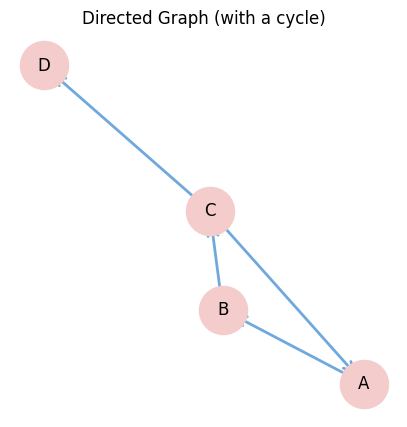

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()
edges = [("A", "B"), ("B", "C"), ("C", "A"), ("C", "D")]
G.add_edges_from(edges)

plt.figure(figsize=(5,5))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="#f4cccc")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=18, edge_color="#6fa8dc", width=2)
nx.draw_networkx_labels(G, pos, font_size=12)
plt.title("Directed Graph (with a cycle)")
plt.axis("off")
plt.show()


Input features:
 tensor([[-0.0750,  1.6444,  0.9196,  0.3568,  1.8671],
        [ 0.9381,  0.5479, -0.6754,  0.0459,  0.5359],
        [-0.2209,  0.2865, -1.2041,  2.2477,  0.3752],
        [-0.6613,  0.5488, -1.4507,  1.0295,  2.1215],
        [-1.8798,  1.2495,  0.5660, -1.0970,  0.1985],
        [-0.4459,  0.3556,  1.3865,  1.1234, -1.3733],
        [-0.1812,  1.2897, -0.9503, -0.7446,  0.5415],
        [ 0.0036, -0.0591,  0.0355, -0.3486, -1.3444],
        [ 1.4451,  0.0131,  0.3520, -0.4997, -0.4650],
        [-0.4430, -0.3453, -0.8899, -0.7570,  1.3638]])
Output features:
 tensor([[-0.2614,  0.4974],
        [-0.3395,  0.5945],
        [-0.3393,  0.6555],
        [-0.2701,  0.6694],
        [-0.2274,  0.7238],
        [-0.2949,  0.6250],
        [-0.2749,  0.5218],
        [-0.1775,  0.3444],
        [-0.0569,  0.2058],
        [-0.0252,  0.1032]], grad_fn=<AddBackward0>)


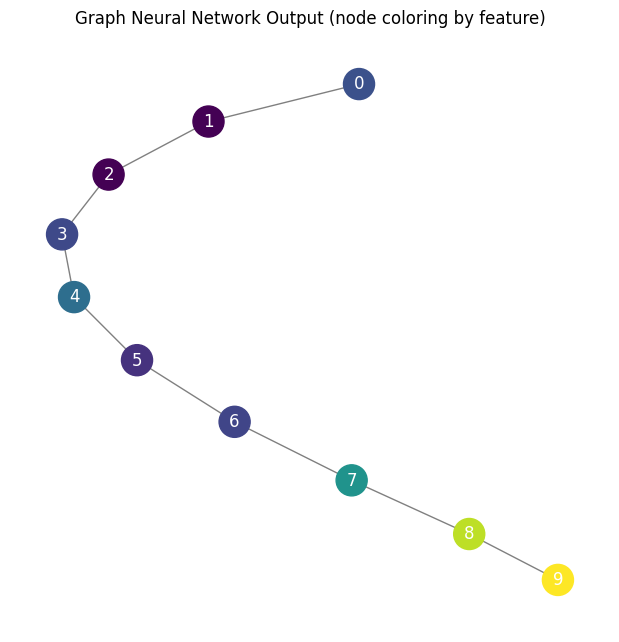

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import networkx as nx
import matplotlib.pyplot as plt

# ---- Step 1: Create synthetic graph data ----
num_nodes = 10
num_node_features = 5

# Node features sampled from normal distribution N(0,1)
x = torch.randn((num_nodes, num_node_features))

# Example edges (simple chain graph: 0-1-2-...-9)
edge_index = torch.tensor(
    [[i, i+1] for i in range(num_nodes-1)] +
    [[i+1, i] for i in range(num_nodes-1)],  # undirected edges
    dtype=torch.long
).t().contiguous()

# Graph data
data = Data(x=x, edge_index=edge_index)

# ---- Step 2: Define GNN model ----
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# ---- Step 3: Train/test forward pass ----
model = GNN(in_channels=num_node_features, hidden_channels=16, out_channels=2)
out = model(data)

print("Input features:\n", data.x)
print("Output features:\n", out)

# ---- Step 4: Visualization ----
# Convert PyG edge_index to networkx format
edge_list = edge_index.t().tolist()
G = nx.Graph()
G.add_edges_from(edge_list)

# Use the first output dimension as node color
node_colors = out[:, 0].detach().numpy()

plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, seed=42)  # nicer layout
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    node_size=500,
    font_color="white",
    edge_color="gray"
)
plt.title("Graph Neural Network Output (node coloring by feature)")
plt.show()


In Graph Neural Networks:

Layers are usually message-passing layers.

Each layer updates node features by:

Collecting (aggregating) messages from its neighbors.

Transforming with a learnable weight (like nn.Linear).

So a GNN still has “layer 1, layer 2, layer 3”, but instead of dense/conv layers, you use graph layers like GCNConv, GraphSAGEConv, GATConv, etc.

🔹 What is a generic GNN layer?

At its heart, every GNN layer does message passing:

Message function → send info from node 
j
j to neighbor 
i
i

mij=M(hi,hj,eij)
m
ij
	​

=M(h
i
	​

,h
j
	​

,e
ij
	​

)

Aggregation function → combine messages from all neighbors

mi=∑j∈N(i)mij
m
i
	​

=
j∈N(i)
∑
	​

m
ij
	​


Update function → update node feature

hi(l+1)=U(hi(l),mi)
h
i
(l+1)
	​

=U(h
i
(l)
	​

,m
i
	​

)

Here, 
M
M, 
U
U can be simple linear layers or MLPs.

Weighted Adjacency Matrix (A):
[[0.9 0.5 0.  0.  1.2]
 [0.5 0.9 0.8 0.  0. ]
 [0.  0.8 0.9 1.  0. ]
 [0.  0.  1.  0.9 0.7]
 [1.2 0.  0.  0.7 0.9]]

Normalized Adjacency Matrix (\hat{A}):
[[0.34615386 0.20906049 0.         0.         0.4447496 ]
 [0.20906049 0.40909085 0.32824394 0.         0.        ]
 [0.         0.32824394 0.33333328 0.37742567 0.        ]
 [0.         0.         0.37742567 0.34615386 0.25943726]
 [0.4447496  0.         0.         0.25943726 0.32142854]]

Input Features (H0):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [-0.7581,  1.0783,  0.8008,  1.6806],
        [ 0.3559, -0.6866, -0.4934,  0.2415],
        [-0.2316,  0.0418, -0.2516,  0.8599],
        [-0.3097, -0.3957,  0.8034, -0.6216]])

Features after Layer 1 (H1):
tensor([[-5.9999e-04,  1.2134e+00, -6.4159e-02, -2.6547e+00],
        [-8.2896e-01,  1.1243e+00,  4.7212e-01, -3.9941e-02],
        [-1.4255e+00,  1.0024e+00,  1.9856e-01,  2.2164e+00],
        [-2.6049e-01, -3.4157e-02, -4.6319e-01,  8.61

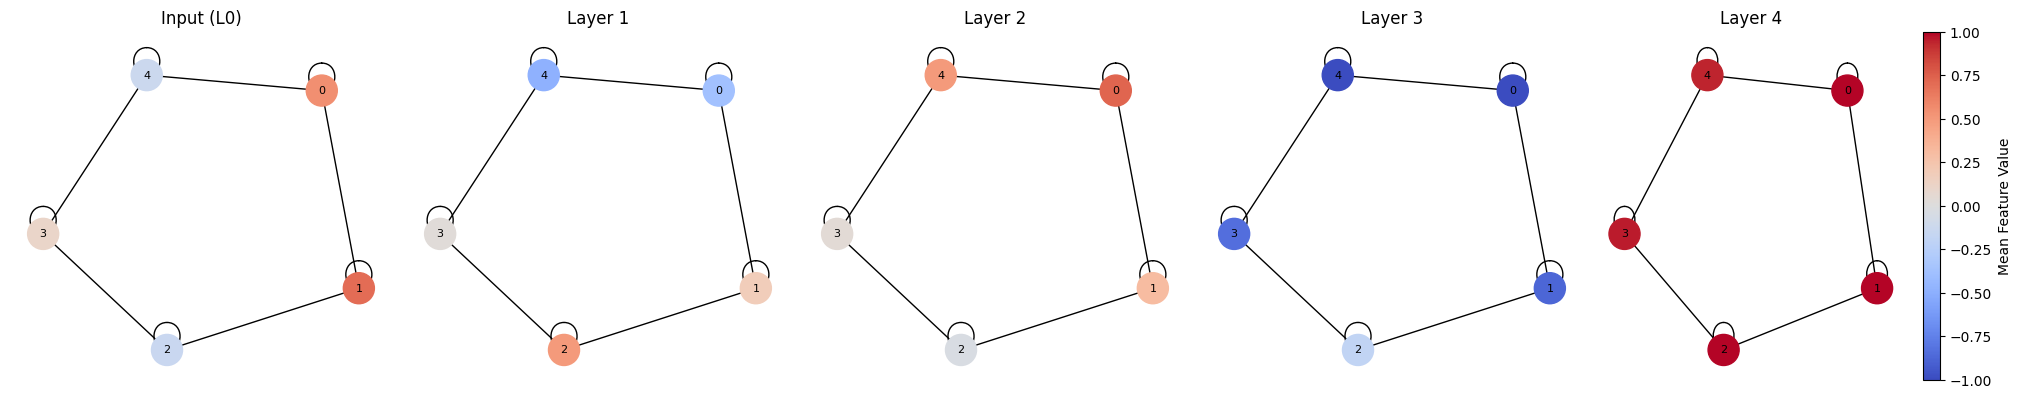

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

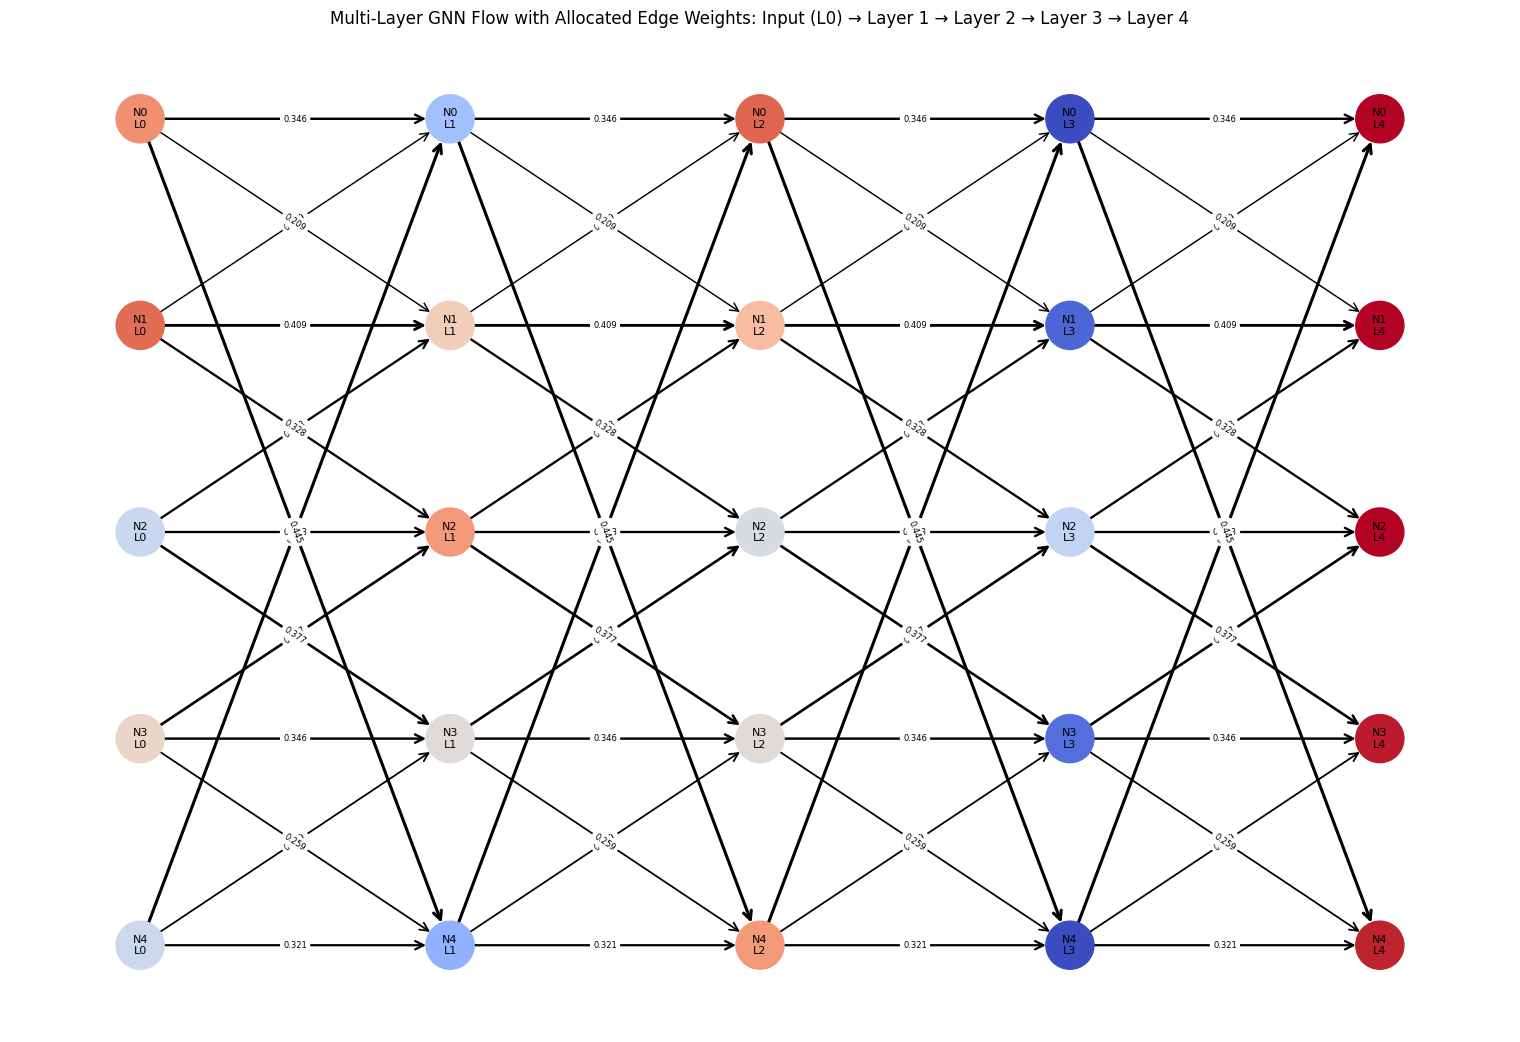

In [21]:
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# Create a cycle graph with 5 nodes
G = nx.cycle_graph(5)
N = 5

# Allocate specific weights to edges (including self-loops)
edge_weights = {
    (0,0): 0.9, (0,1): 0.5, (1,0): 0.5, (0,4): 1.2, (4,0): 1.2,
    (1,1): 0.9, (1,2): 0.8, (2,1): 0.8,
    (2,2): 0.9, (2,3): 1.0, (3,2): 1.0,
    (3,3): 0.9, (3,4): 0.7, (4,3): 0.7,
    (4,4): 0.9
}
G.add_weighted_edges_from([(u, v, w) for (u, v), w in edge_weights.items()])

# Weighted adjacency matrix
adj = nx.to_numpy_array(G)
adj = torch.tensor(adj, dtype=torch.float)
print("Weighted Adjacency Matrix (A):")
print(adj.numpy())

# Normalize adjacency matrix: \hat{A} = D^{-1/2} A D^{-1/2}
degrees = adj.sum(dim=1)
D_inv_sqrt = torch.diag(1.0 / torch.sqrt(degrees + 1e-10))  # Avoid division by zero
adj_hat = D_inv_sqrt @ adj @ D_inv_sqrt
print("\nNormalized Adjacency Matrix (\hat{A}):")
print(adj_hat.numpy())

# Input features: 5 nodes, 4 dimensions from normal distribution
in_dim = 4
features = torch.randn(N, in_dim)
print("\nInput Features (H0):")
print(features)

# Define GCN layer
class GCNLayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = torch.nn.Parameter(torch.randn(in_dim, out_dim))

    def forward(self, x, adj):
        support = x @ self.W
        out = adj @ support
        return out

# Initialize 4 GCN layers
layers = [GCNLayer(in_dim, in_dim) for _ in range(4)]

# Forward pass through 4 layers
H = [features]
for i, layer in enumerate(layers, 1):
    H.append(layer(H[-1], adj_hat).detach())
    print(f"\nFeatures after Layer {i} (H{i}):")
    print(H[-1])

# Compute mean feature values for coloring
means = [np.mean(h.numpy(), axis=1) for h in H]

# Visualization 1: Graph Visualization
pos = nx.spring_layout(G, seed=42)
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
titles = ["Input (L0)", "Layer 1", "Layer 2", "Layer 3", "Layer 4"]
for idx, ax in enumerate(axs):
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=means[idx], 
            cmap='coolwarm', node_size=500, font_size=8, vmin=-1, vmax=1)
    ax.set_title(titles[idx])
plt.tight_layout()
plt.colorbar(plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1)), 
             ax=axs[-1], label='Mean Feature Value')
plt.show()
# Optional: plt.savefig('gnn_weighted_cycle_graph.png')

# Visualization 2: Flow Diagram with Allocated Edge Weights
G_flow = nx.DiGraph()
flow_pos = {}
node_colors = []
node_labels = {}
num_layers = 5
for l in range(num_layers):
    for i in range(N):
        node_id = f'L{l}_{i}'
        G_flow.add_node(node_id)
        flow_pos[node_id] = (l, -i)
        node_colors.append(means[l][i])
        node_labels[node_id] = f'N{i}\nL{l}'
edge_labels = {}
edge_widths = []
for l in range(1, num_layers):
    for i in range(N):
        for j in range(N):
            if adj[i, j] > 0:
                weight = adj_hat[i, j].item()
                G_flow.add_edge(f'L{l-1}_{j}', f'L{l}_{i}')
                edge_labels[(f'L{l-1}_{j}', f'L{l}_{i}')] = f'{weight:.3f}'
                edge_widths.append(weight * 5)  # Scale for visibility
plt.figure(figsize=(15, 10))
nx.draw(G_flow, flow_pos, with_labels=True, labels=node_labels, node_color=node_colors, 
        cmap='coolwarm', node_size=1200, font_size=8, arrows=True, arrowstyle='->', arrowsize=15, 
        width=edge_widths, vmin=-1, vmax=1)
nx.draw_networkx_edge_labels(G_flow, flow_pos, edge_labels=edge_labels, font_size=6)
plt.title("Multi-Layer GNN Flow with Allocated Edge Weights: Input (L0) → Layer 1 → Layer 2 → Layer 3 → Layer 4")
plt.colorbar(plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1)), 
             label='Mean Feature Value')
plt.show()
# Optional: plt.savefig('gnn_flow_allocated_weights.png')

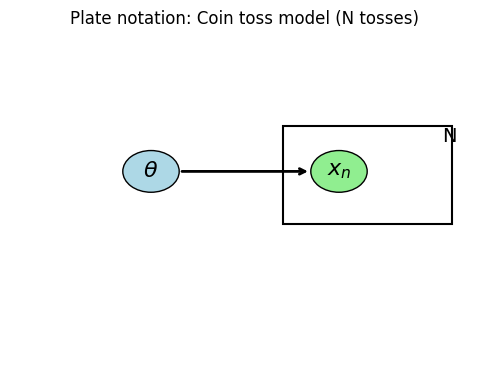

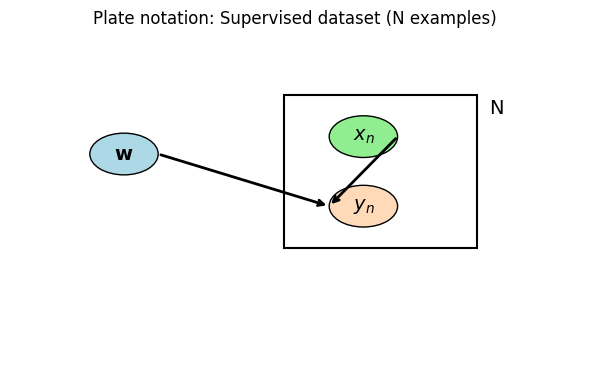

('plate_coin.png', 'plate_dataset.png')

In [22]:
# Re-run the plate drawing script. This will create two images showing plate notation examples.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_coin_toss_plate(save_path="plate_coin.png"):
    fig, ax = plt.subplots(figsize=(5,4))
    ax.axis('off')

    # Draw theta node
    theta_center = (0.3, 0.6)
    ax.add_patch(plt.Circle(theta_center, 0.06, color='lightblue', ec='k'))
    ax.text(theta_center[0], theta_center[1], r'$\theta$', ha='center', va='center', fontsize=16)

    # Draw x_n node (single representative)
    x_center = (0.7, 0.6)
    ax.add_patch(plt.Circle(x_center, 0.06, color='lightgreen', ec='k'))
    ax.text(x_center[0], x_center[1], r'$x_n$', ha='center', va='center', fontsize=16)

    # Arrow theta -> x_n
    ax.annotate("", xy=(x_center[0]-0.06, x_center[1]), xytext=(theta_center[0]+0.06, theta_center[1]),
                arrowprops=dict(arrowstyle="->", lw=2))

    # Draw plate (rectangle) around x_n with label N
    plate = patches.Rectangle((0.58, 0.45), 0.36, 0.28, linewidth=1.5, edgecolor='k', facecolor='none')
    ax.add_patch(plate)
    ax.text(0.92, 0.7, "N", fontsize=14, va='center')

    ax.set_title("Plate notation: Coin toss model (N tosses)")
    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    return save_path

def draw_dataset_plate(save_path="plate_dataset.png"):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.axis('off')

    # Draw global parameter w
    w_center = (0.2, 0.65)
    ax.add_patch(plt.Circle(w_center, 0.06, color='lightblue', ec='k'))
    ax.text(w_center[0], w_center[1], r'$\mathbf{w}$', ha='center', va='center', fontsize=14)

    # Draw latent/observed inside plate: x_n and y_n vertically
    x_center = (0.62, 0.7)
    y_center = (0.62, 0.5)
    ax.add_patch(plt.Circle(x_center, 0.06, color='lightgreen', ec='k'))
    ax.text(x_center[0], x_center[1], r'$x_n$', ha='center', va='center', fontsize=14)
    ax.add_patch(plt.Circle(y_center, 0.06, color='peachpuff', ec='k'))
    ax.text(y_center[0], y_center[1], r'$y_n$', ha='center', va='center', fontsize=14)

    # Arrows w -> y_n and x_n -> y_n
    ax.annotate("", xy=(y_center[0]-0.06, y_center[1]), xytext=(w_center[0]+0.06, w_center[1]),
                arrowprops=dict(arrowstyle="->", lw=2))
    ax.annotate("", xy=(y_center[0]-0.06, y_center[1]), xytext=(x_center[0]+0.06, x_center[1]),
                arrowprops=dict(arrowstyle="->", lw=2))

    # Draw plate around x_n and y_n
    plate = patches.Rectangle((0.48, 0.38), 0.34, 0.44, linewidth=1.5, edgecolor='k', facecolor='none')
    ax.add_patch(plate)
    ax.text(0.84, 0.78, "N", fontsize=14, va='center')

    ax.set_title("Plate notation: Supervised dataset (N examples)")
    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    return save_path

coin_path = draw_coin_toss_plate()
data_path = draw_dataset_plate()

coin_path, data_path


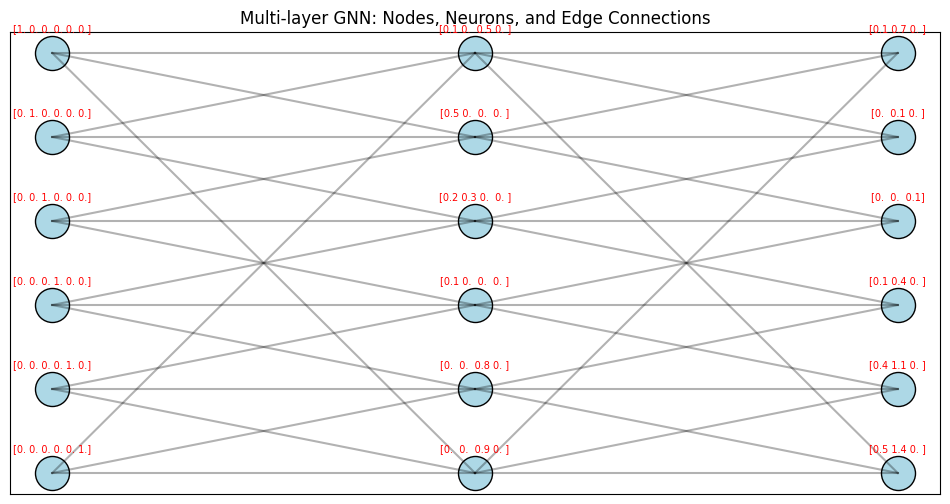

In [26]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ---- Step 1: Build a graph (6 nodes in a cycle) ----
G = nx.cycle_graph(6)
N = G.number_of_nodes()
X = np.eye(N)

# ---- Step 2: Normalize adjacency ----
A = nx.to_numpy_array(G)
I = np.eye(N)
A_hat = A + I
D_hat = np.diag(np.sum(A_hat, axis=1))
D_hat_inv = np.linalg.inv(D_hat)
A_norm = D_hat_inv @ A_hat

# ---- Step 3: Multi-layer forward pass ----
np.random.seed(3)
layers = [X]  # input features as layer 0
W1 = np.random.randn(N, 4)
W2 = np.random.randn(4, 3)

H1 = np.maximum(A_norm @ layers[0] @ W1, 0)
H2 = np.maximum(A_norm @ H1 @ W2, 0)
layers.append(H1)
layers.append(H2)

# ---- Step 4: Visualization (layered network) ----
def plot_multilayer(layers, G):
    num_layers = len(layers)
    N = G.number_of_nodes()
    plt.figure(figsize=(12, 6))

    # assign positions
    pos = {}
    for l in range(num_layers):
        for n in range(N):
            pos[(l, n)] = (l, -n)

    # draw nodes for each layer
    for l in range(num_layers):
        nx.draw_networkx_nodes(
            G, pos, nodelist=[(l, n) for n in range(N)],
            node_color="lightblue", node_size=600, edgecolors="black"
        )
        # annotate embeddings
        for n in range(N):
            emb = layers[l][n].round(1)
            plt.text(l, -n+0.25, f"{emb}", fontsize=7, ha="center", color="red")

    # draw inter-layer edges based on graph structure
    for l in range(num_layers-1):
        for u, v in G.edges():
            plt.plot([l, l+1], [-u, -v], "k-", alpha=0.3)
            plt.plot([l, l+1], [-v, -u], "k-", alpha=0.3)
        for n in range(N):  # self-loops
            plt.plot([l, l+1], [-n, -n], "k-", alpha=0.3)

    plt.xticks(range(num_layers), [f"Layer {i}" for i in range(num_layers)])
    plt.yticks([])
    plt.title("Multi-layer GNN: Nodes, Neurons, and Edge Connections")
    plt.show()

plot_multilayer(layers, G)


/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10987 (\N{DOUBLE UP TACK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


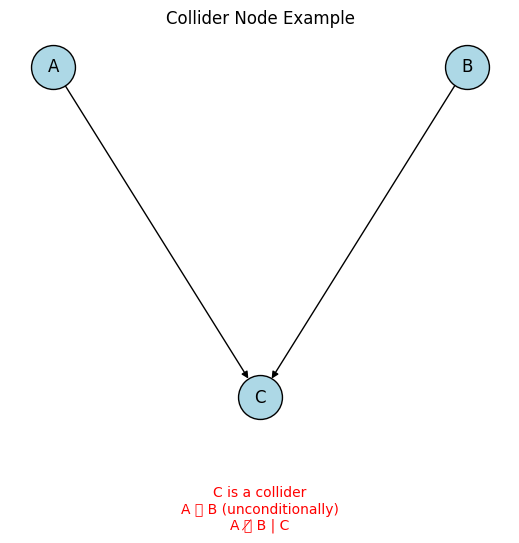

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# ---- Step 1: Build a collider graph A -> C <- B ----
G = nx.DiGraph()
edges = [("A", "C"), ("B", "C")]
G.add_edges_from(edges)

# ---- Step 2: Visualize ----
pos = {"A": (-1, 0), "B": (1, 0), "C": (0, -1)}

plt.figure(figsize=(5,4))
nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=1000, edgecolors="black", arrows=True)

# annotate collider property
plt.text(0, -1.4, "C is a collider\nA ⟂ B (unconditionally)\nA ⫫̸ B | C", 
         ha="center", fontsize=10, color="red")

plt.title("Collider Node Example")
plt.show()
